In [1]:
#julia -t 4

using Plots
using Random, Statistics, Distributions
using SparseArrays
using LinearAlgebra
using DifferentialEquations
using StatsPlots 

using Statistics 
using Distributions, Random, Plots, StatsBase  
using Base.Threads



In [ ]:


# -------------------------
# RBF Kernel
# -------------------------
function rbf_kernel(x1, x2; ℓ=1.0, σf=1.0)
    σf^2 * exp(-(x1 - x2)^2 / (2ℓ^2))
end

function kernel_matrix(X1, X2; ℓ=1.0, σf=1.0)
    [rbf_kernel(x1, x2; ℓ=ℓ, σf=σf) for x1 in X1, x2 in X2]
end

# -------------------------
# Training Data
# -------------------------


X_train = collect(range(-4, 4, length=20))

y_train = sin.(X_train) .+
          0.2 .* randn(length(X_train)) 

σf = 1.0
σn = 0.2

 
#

0.2

In [6]:

# -------------------------
# GP Hyperparameter tuning
# -------------------------


function log_marginal_likelihood(X, y; ℓ, σf, σn)
    K = kernel_matrix(X, X; ℓ=ℓ, σf=σf) + σn^2 * I

    L = cholesky(Hermitian(K)).L
    α = L' \ (L \ y)

    n = length(y)
    logdetK = 2sum(log.(diag(L)))

    return -0.5 * y' * α - 0.5 * logdetK - 0.5 * n * log(2π)
end

ℓ_candidates = [0.1, 0.3, 1.0, 3.0, 10.0]

best_ℓ = nothing
best_ll = -Inf

for ℓ_try in ℓ_candidates

    ll = log_marginal_likelihood(X_train, y_train;
                                  ℓ=ℓ_try,
                                  σf=1.0,
                                  σn=0.2)

    println("ℓ = ", ℓ_try, "  logML = ", ll)

    if ll > best_ll
        best_ll = ll
        best_ℓ = ℓ_try
    end
end

println("\nBest ℓ = ", best_ℓ, " (logML = ", best_ll, ")")

ℓ = 0.1  logML = -22.424463903868585
ℓ = 0.3  logML = -19.847606986964028
ℓ = 1.0  logML = -7.507372828651754
ℓ = 3.0  logML = -17.49475097122911
ℓ = 10.0  logML = -79.5809201264547

Best ℓ = 1.0 (logML = -7.507372828651754)


In [7]:

σf = 1.0
σn = 0.2

# -------------------------
# Test Points
# -------------------------
X_test = collect(range(-5, 5, length=300))

# -------------------------
# Covariance Matrices
# -------------------------
K =
    kernel_matrix(X_train, X_train;
                  ℓ=ℓ, σf=σf) +
    σn^2 * I

Ks =
    kernel_matrix(X_train, X_test;
                  ℓ=ℓ, σf=σf)

Kss =
    kernel_matrix(X_test, X_test;
                  ℓ=ℓ, σf=σf)

# -------------------------
# Posterior Mean
# -------------------------
μ =
    transpose(Ks) *
    (K \ y_train)

# -------------------------
# Posterior Covariance
# -------------------------
Σ =
    Kss -
    transpose(Ks) *
    (K \ Ks)

std =
    sqrt.(diag(Σ))

#

300-element Vector{Float64}:
 0.7123282646655369
 0.6948141564338861
 0.6768074941505932
 0.6583390588377155
 0.6394430721894447
 0.6201571400179535
 0.6005221748404339
 0.5805822988411453
 0.5603847288336887
 0.539979645243343
 ⋮
 0.5603847288336885
 0.580582298841145
 0.6005221748404337
 0.6201571400179534
 0.6394430721894446
 0.6583390588377153
 0.6768074941505933
 0.6948141564338861
 0.7123282646655369

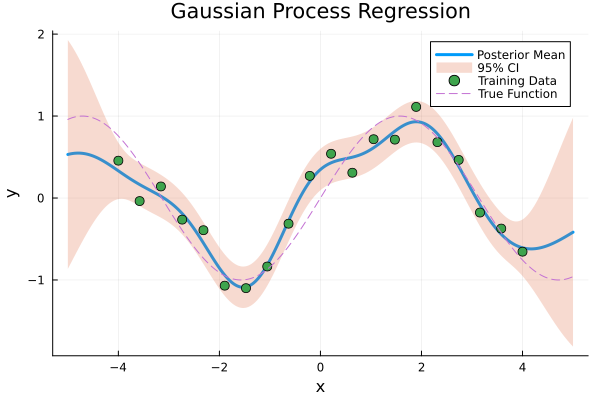

In [8]:
#-------------------------
# Visualization
# -------------------------
plot(
    X_test,
    μ,
    label="Posterior Mean",
    lw=3
)

plot!(
    X_test,
    μ .+ 1.96 .* std,
    fillrange=μ .- 1.96 .* std,
    fillalpha=0.25,
    linealpha=0,
    label="95% CI"
)

scatter!(
    X_train,
    y_train,
    label="Training Data",
    ms=5
)

plot!(
    X_test,
    sin.(X_test),
    ls=:dash,
    label="True Function"
)

xlabel!("x")
ylabel!("y")
title!("Gaussian Process Regression")